In [20]:
import tensorflow as tf

# Check which devices are available
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

print("Physical GPUs Found:", gpus)
print("Physical CPUs Found:", cpus)

# Check which device is actually being used for a simple calculation
with tf.device(None): # Let TF pick the default
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
    c = tf.matmul(a, b)
    print("\nDefault device for operations:", c.device)

Physical GPUs Found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Physical CPUs Found: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

Default device for operations: /job:localhost/replica:0/task:0/device:GPU:0


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras.utils import image_dataset_from_directory # pyright: ignore[reportMissingImports]
import pickle



## Data Preparation

In [21]:

training_set = image_dataset_from_directory(
    "train",
    labels="inferred", # Consider any subfolder name as a label - CNV, DME, DRUSEN, NORMAL are each one label
    label_mode="categorical", # changed from "int" to "categorical" for multi-class classification
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224), # MobileNetV3Large expects 224x224 input size
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)


Found 76515 files belonging to 4 classes.


In [5]:

validation_set = image_dataset_from_directory(
    "val",
    labels="inferred", # Consider any subfolder name as a label - CNV, DME, DRUSEN, NORMAL are each one label
    label_mode="categorical", # changed from "int" to "categorical" for multi-class classification
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)


Found 21861 files belonging to 4 classes.


In [23]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [24]:
validation_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [25]:
INPUT_SHAPE = (224, 224, 3) # height, width, channels

In [26]:
MobNet = tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling=None,
    dropout_rate=0.2,
    classifier_activation="softmax", 
    include_preprocessing=True,
    # name="MobileNetV3Large",
) 

In [9]:
# MobNet.trainable = False
# This means we are freezing the MobileNetV3Large layers during training, 
# so only the new layers we add on top will be trained. 
# This is a common practice in transfer learning to leverage the pre-trained features while preventing overfitting on the new dataset.
# But since we have a large dataset, we dont need to do transfer learning, we can just train the model from scratch. 
# So we will set trainable to True.

In [27]:
model = tf.keras.models.Sequential()

# Sequential model is a linear stack of layers. 
# We will add layers to this model one by one.

In [28]:
model.add(tf.keras.Input(shape=INPUT_SHAPE))

# This is the input layer that defines the shape of the input data.
# It tells the model to expect images of size 256x256 pixels with 3 color channels (RGB).

In [29]:
model.add(MobNet)

# This adds the MobileNetV3Large model as a layer in our Sequential model.
# MobileNet will act as a feature extractor, taking the input images and extracting relevant features for classification.

In [30]:
model.add(tf.keras.layers.Dense(units=4, activation="softmax")) # 4 classes: CNV, DME, DRUSEN, NORMAL

# Dense layer is like a decision layer that takes the features extracted by MobileNet and makes the final classification into one of the 4 classes. 
# The "softmax" activation ensures the output is a probability distribution across the 4 classes.

In [ ]:
import tensorflow.keras.backend as K

def f1_score(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2 * (precision * recall) / (precision + recall + K.epsilon())
    return f1_val

In [32]:
metrics_list = ["accuracy",
           tf.keras.metrics.Precision(name="precision"),
           tf.keras.metrics.Recall(name="recall"),
           tf.keras.metrics.AUC(name="auc"),
           f1_score # Added F1 Score for multi-class classification
           ]
# These are the metrics we want to track during training to monitor the performance of our model.
# Accuracy gives us the overall correctness, Precision and Recall help us understand the performance on each class
# AUC gives us insight into the model's ability to distinguish between classes, 
# and F1 Score provides a balance between Precision and Recall, 
# especially useful when we have class imbalance.

In [33]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy", # Changed from "sparse_categorical_crossentropy" to "categorical_crossentropy" for multi-class classification with one-hot encoded labels
    metrics=metrics_list
)

In [34]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense_1 (Dense)             (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [ ]:
training_history = model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=15
)

In [ ]:
model.save("Trained_Model.h5")

In [ ]:
model.save("Trained_Model.keras")
# Saving in both .h5 and .keras formats for compatibility and future use.
# If we have a legacy Adam optimizer or custom objects, we can load the .h5 format.
# The .keras format is the newer standard and is recommended for future use, but .h5 can be useful for backward compatibility.

In [ ]:
# Saving history
with open('Training_history.pkl', 'wb') as f:
    pickle.dump(training_history.history, f)

In [2]:
#Reloading History from pickle
with open('Training_history.pkl', 'rb') as f:
    load_history = pickle.load(f)
load_history

{'loss': [1.1453802585601807,
  0.8648024201393127,
  0.6702404618263245,
  0.5356669425964355,
  0.4320599436759949,
  0.3479674160480499,
  0.28923746943473816,
  0.24451656639575958,
  0.20830342173576355,
  0.18285790085792542,
  0.1699090301990509,
  0.1487247496843338,
  0.1339232176542282,
  0.12125182151794434,
  0.11251933872699738],
 'accuracy': [0.8422400951385498,
  0.887708306312561,
  0.8857740163803101,
  0.9060314893722534,
  0.9422466158866882,
  0.9499706029891968,
  0.9534600973129272,
  0.9567012786865234,
  0.9605175256729126,
  0.962582528591156,
  0.9621120095252991,
  0.9666078686714172,
  0.9693262577056885,
  0.9716918468475342,
  0.9733254909515381],
 'f1_score': [array([0.8814868 , 0.57463247, 0.00095801, 0.92311895], dtype=float32),
  array([0.9090779 , 0.8804841 , 0.        , 0.94674116], dtype=float32),
  array([0.9392844 , 0.89636165, 0.        , 0.9176859 ], dtype=float32),
  array([0.9481992 , 0.90421456, 0.37415048, 0.9337706 ], dtype=float32),
  arra

In [3]:
# We add *args and **kwargs so it absorbs 'name' or any other hidden settings
def F1Score(*args, **kwargs):
    return 0 

# Load the model again
try:
    model = tf.keras.models.load_model(
        'Trained_Model.h5', 
        custom_objects={'F1Score': F1Score},
        compile=False # This is the "Nuclear Option" to stop metric errors entirely
    )
    
    # Since we used compile=False, we re-compile it with standard metrics 
    # so we don't have to deal with the guy's custom F1 code anymore.
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    print("✅ SUCCESS: Model loaded and re-compiled with standard metrics.")
    model.summary()
except Exception as e:
    print(f"❌ Still hitting a wall: {e}")

✅ SUCCESS: Model loaded and re-compiled with standard metrics.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense (Dense)               (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [8]:
# Predict on a small sample
for images, labels in validation_set.take(1):
    sample_preds = model.predict(images)
    print("Top confidence for first image:", np.max(sample_preds[0]))
    print("Predicted Class Index:", np.argmax(sample_preds[0]))
    break

1/1 [==============================] - 0s 61ms/step
Top confidence for first image: 0.97890085
Predicted Class Index: 3


In [9]:
load_history.keys()

dict_keys(['loss', 'accuracy', 'f1_score', 'val_loss', 'val_accuracy', 'val_f1_score'])

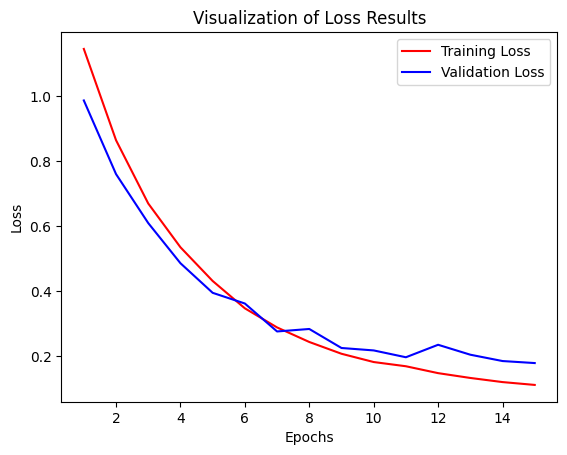

In [10]:
# Loss Visualization

epochs = [i for i in range(1, 16)] # Range is from 1 to number of epochs + 1 because range is exclusive on the end
plt.plot(epochs, load_history['loss'], color='red', label='Training Loss')
plt.plot(epochs, load_history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Visualization of Loss Results")
plt.legend()
plt.show()

## Model Evaluation

In [11]:
# We add *args and **kwargs so it absorbs 'name' or any other hidden settings
def F1Score(*args, **kwargs):
    return 0 

# Load the model again
try:
    model = tf.keras.models.load_model(
        'Trained_Model.h5', 
        custom_objects={'F1Score': F1Score},
        compile=False # This is the "Nuclear Option" to stop metric errors entirely
    )
    
    # Since we used compile=False, we re-compile it with standard metrics 
    # so we don't have to deal with the guy's custom F1 code anymore.
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    print("✅ SUCCESS: Model loaded and re-compiled with standard metrics.")
    model.summary()
except Exception as e:
    print(f"❌ Still hitting a wall: {e}")

✅ SUCCESS: Model loaded and re-compiled with standard metrics.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense (Dense)               (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [19]:

test_set = image_dataset_from_directory(
    "test",
    labels="inferred", # Consider any subfolder name as a label - CNV, DME, DRUSEN, NORMAL are each one label
    label_mode="categorical", # changed from "int" to "categorical" for multi-class classification
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224), # MobileNetV3Large expects 224x224 input size
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)


Found 10933 files belonging to 4 classes.


In [20]:
test_loss, test_accuracy = model.evaluate(test_set)

342/342 [==============================] - 23s 68ms/step - loss: 0.1883 - accuracy: 0.9476


In [21]:
test_loss, test_accuracy

(0.18833324313163757, 0.9475898742675781)

In [22]:
# Computing True label from the test set

true_categories = tf.concat([y for x, y in test_set], axis=0) 
# x is all the features (images) and y is all the labels, 
# we concatenate all the labels together to get the true categories for the entire test set.

y_true = tf.argmax(true_categories, axis=1) # Convert one-hot encoded labels to class indices
y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [23]:
# Computing predicted labels using test set
predicted_categories = model.predict(test_set)
predicted_categories

342/342 [==============================] - 23s 66ms/step


array([[0.9797176 , 0.00501773, 0.01007493, 0.00518976],
       [0.9797176 , 0.00501773, 0.01007493, 0.00518976],
       [0.9797176 , 0.00501773, 0.01007493, 0.00518976],
       ...,
       [0.00375679, 0.00579205, 0.00922175, 0.98122936],
       [0.00372836, 0.0057465 , 0.00914705, 0.98137814],
       [0.00372624, 0.00574432, 0.00914029, 0.9813891 ]], dtype=float32)

In [24]:
Y_Pred = tf.argmax(predicted_categories, axis=1)
Y_Pred

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

### 1. Classification Report

In [ ]:
from sklearn.metrics import classification_report

In [26]:
print("Classification Report:\n", classification_report(y_true, Y_Pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96      3746
           1       0.95      0.88      0.91      1161
           2       0.79      0.79      0.79       887
           3       0.96      0.99      0.97      5139

    accuracy                           0.95     10933
   macro avg       0.92      0.90      0.91     10933
weighted avg       0.95      0.95      0.95     10933



### 2. Confusion Matrix

In [27]:
from sklearn.metrics import confusion_matrix

In [28]:
cm = confusion_matrix(y_true, Y_Pred)
cm

array([[3577,   23,  122,   24],
       [  19, 1020,   13,  109],
       [  75,   10,  700,  102],
       [   4,   17,   55, 5063]], dtype=int64)

In [38]:
# 23 examples that the model predicts for the first class while the true label is the second class, which is a misclassification.

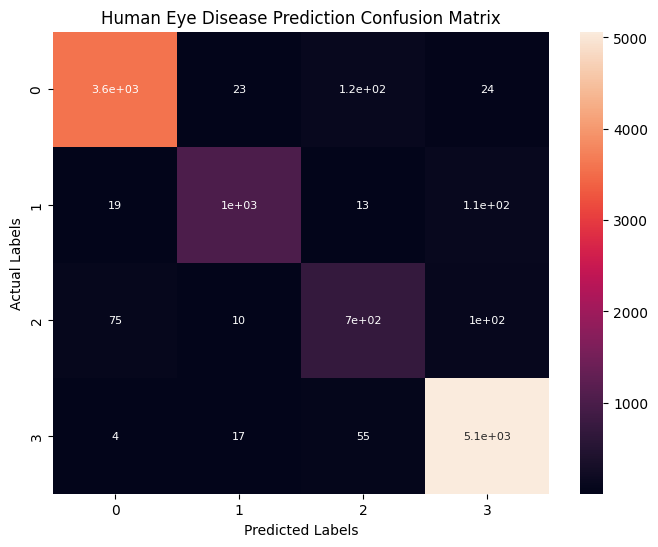

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, annot_kws={"size": 8})
plt.xlabel('Predicted Labels', fontsize=10)
plt.ylabel('Actual Labels', fontsize=10)
plt.title("Human Eye Disease Prediction Confusion Matrix", fontsize=12)
plt.show()